In [2]:
# Question 5(a): Implementing Linear Prediction
# Apply LP of order N on each STFT frame (25ms window, 10ms shift, Hamming window)
# Plot energy of residual signal for each frame

import numpy as np
import scipy.io.wavfile as wav
from scipy.signal.windows import hamming
from scipy.signal import lfilter
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt

# Load the audio file
sample_rate, audio = wav.read('dataFiles/Train_0_Example_1.wav')
audio = audio.astype(np.float64)

# Normalize audio
audio = audio / np.max(np.abs(audio))

print(f"Sample Rate: {sample_rate} Hz")
print(f"Audio Length: {len(audio)} samples ({len(audio)/sample_rate:.3f} seconds)")

Sample Rate: 16000 Hz
Audio Length: 18204 samples (1.138 seconds)


In [3]:
# STFT Parameters
window_duration = 0.025  # 25 ms
hop_duration = 0.010     # 10 ms shift

window_length = int(window_duration * sample_rate)
hop_length = int(hop_duration * sample_rate)

print(f"Window Length: {window_length} samples ({window_duration*1000} ms)")
print(f"Hop Length: {hop_length} samples ({hop_duration*1000} ms)")

# Create Hamming window
window = hamming(window_length)

# Calculate number of frames
num_frames = (len(audio) - window_length) // hop_length + 1
print(f"Number of Frames: {num_frames}")

Window Length: 400 samples (25.0 ms)
Hop Length: 160 samples (10.0 ms)
Number of Frames: 112


In [4]:
def compute_lp_coefficients(frame, order):
    """
    Compute Linear Prediction coefficients using autocorrelation method
    (Levinson-Durbin algorithm)
    """
    # Compute autocorrelation
    r = np.correlate(frame, frame, mode='full')
    r = r[len(frame)-1:]  # Take only positive lags
    
    # Use only up to order+1 autocorrelation values
    r = r[:order+1]
    
    # Solve using Levinson-Durbin (solve_toeplitz is efficient)
    # R * a = r where R is Toeplitz matrix of r[0:order] and we solve for a[1:order+1]
    if r[0] == 0:
        return np.zeros(order), 0
    
    # Normalize
    r = r / r[0]
    
    # Solve Toeplitz system: R * a = -r[1:order+1]
    R = toeplitz(r[:order])
    a = np.linalg.solve(R, -r[1:order+1])
    
    return a, r[0]

def compute_residual_energy(frame, lp_coeffs):
    """
    Compute residual signal and its energy
    Residual e[n] = x[n] - sum(a[k] * x[n-k]) for k=1 to p
    """
    # Create prediction filter coefficients [1, a1, a2, ..., ap]
    a = np.concatenate([[1], lp_coeffs])
    
    # Filter the signal to get residual (prediction error)
    residual = lfilter(a, [1], frame)
    
    # Compute energy of residual
    energy = np.sum(residual**2)
    
    return energy, residual

In [5]:
# Linear Prediction orders to test
lp_orders = [4, 8, 12, 16, 20]

# Dictionary to store residual energies for each order
residual_energies = {order: [] for order in lp_orders}
frame_energies = []

# Process each frame
for i in range(num_frames):
    # Extract frame
    start = i * hop_length
    end = start + window_length
    frame = audio[start:end] * window
    
    # Compute frame energy (for reference)
    frame_energies.append(np.sum(frame**2))
    
    # Compute LP and residual energy for each order
    for order in lp_orders:
        lp_coeffs, _ = compute_lp_coefficients(frame, order)
        energy, _ = compute_residual_energy(frame, lp_coeffs)
        residual_energies[order].append(energy)

# Convert to numpy arrays
frame_energies = np.array(frame_energies)
for order in lp_orders:
    residual_energies[order] = np.array(residual_energies[order])

print("Processing complete!")

Processing complete!


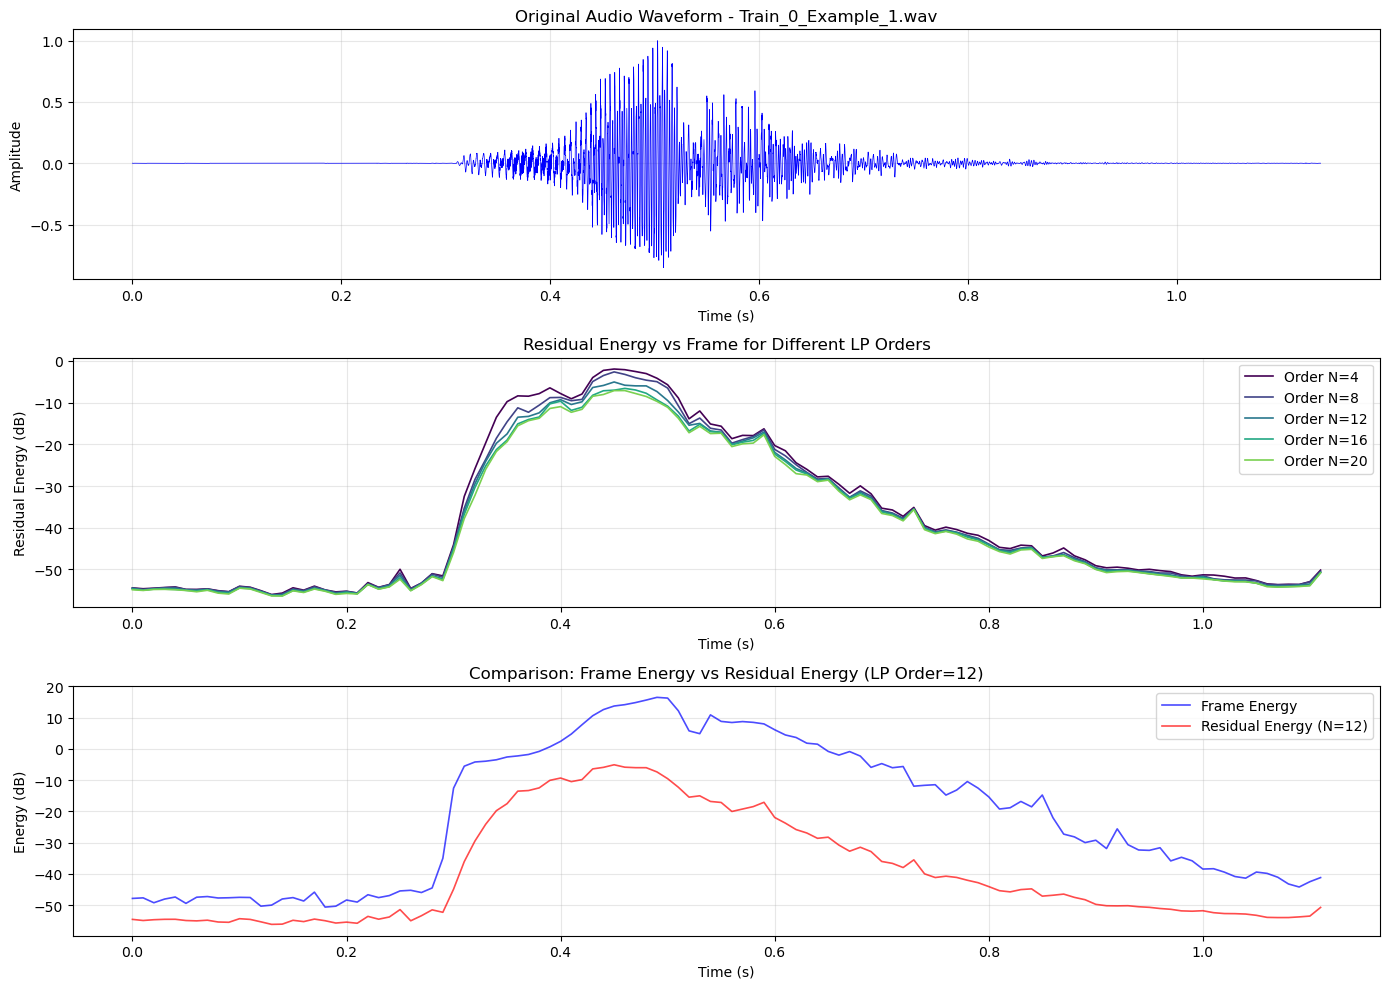

In [6]:
# Create time axis for frames
frame_times = np.arange(num_frames) * hop_duration

# Plot 1: Residual Energy vs Frame for different LP orders
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot original waveform
time_audio = np.arange(len(audio)) / sample_rate
axes[0].plot(time_audio, audio, 'b-', linewidth=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Original Audio Waveform - Train_0_Example_1.wav')
axes[0].grid(True, alpha=0.3)

# Plot residual energies for different orders
colors = plt.cm.viridis(np.linspace(0, 0.8, len(lp_orders)))
for idx, order in enumerate(lp_orders):
    axes[1].plot(frame_times, 10*np.log10(residual_energies[order] + 1e-10), 
                 label=f'Order N={order}', color=colors[idx], linewidth=1.2)

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual Energy (dB)')
axes[1].set_title('Residual Energy vs Frame for Different LP Orders')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot frame energy and residual energy (for order=12)
axes[2].plot(frame_times, 10*np.log10(frame_energies + 1e-10), 
             'b-', label='Frame Energy', linewidth=1.2, alpha=0.7)
axes[2].plot(frame_times, 10*np.log10(residual_energies[12] + 1e-10), 
             'r-', label='Residual Energy (N=12)', linewidth=1.2, alpha=0.7)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Energy (dB)')
axes[2].set_title('Comparison: Frame Energy vs Residual Energy (LP Order=12)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_energy_plot.png', dpi=150, bbox_inches='tight')
plt.show()

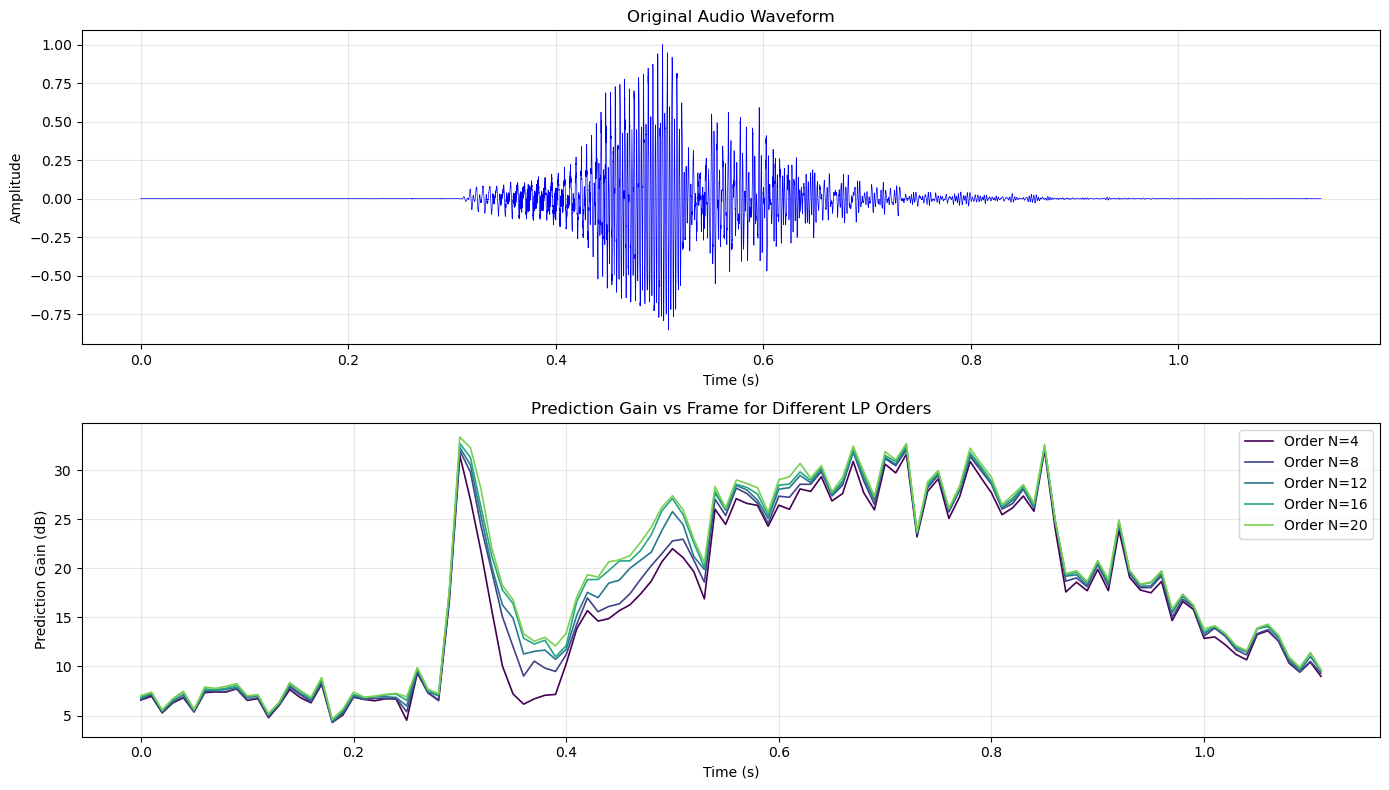


=== Prediction Gain Statistics (dB) ===
Order N=4: Mean=16.64, Max=32.00, Min=4.29
Order N=8: Mean=17.38, Max=32.29, Min=4.33
Order N=12: Mean=17.88, Max=32.34, Min=4.36
Order N=16: Mean=18.26, Max=32.70, Min=4.51
Order N=20: Mean=18.54, Max=33.36, Min=4.62


In [6]:
# Compute Prediction Gain: G = 10*log10(Frame Energy / Residual Energy)
# Higher prediction gain indicates more predictable signal (voiced speech)
# Lower prediction gain indicates less predictable signal (unvoiced/noise)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot original waveform
axes[0].plot(time_audio, audio, 'b-', linewidth=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Original Audio Waveform')
axes[0].grid(True, alpha=0.3)

# Plot prediction gain for different orders
for idx, order in enumerate(lp_orders):
    prediction_gain = 10 * np.log10((frame_energies + 1e-10) / (residual_energies[order] + 1e-10))
    axes[1].plot(frame_times, prediction_gain, 
                 label=f'Order N={order}', color=colors[idx], linewidth=1.2)

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Prediction Gain (dB)')
axes[1].set_title('Prediction Gain vs Frame for Different LP Orders')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_gain_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\n=== Prediction Gain Statistics (dB) ===")
for order in lp_orders:
    prediction_gain = 10 * np.log10((frame_energies + 1e-10) / (residual_energies[order] + 1e-10))
    print(f"Order N={order}: Mean={np.mean(prediction_gain):.2f}, Max={np.max(prediction_gain):.2f}, Min={np.min(prediction_gain):.2f}")

## Analysis: Relating Residual Energy to Speech Sounds

### Key Observations:

**1. Voiced vs Unvoiced Speech:**
- **Low Residual Energy (High Prediction Gain)**: Corresponds to **voiced speech** segments (vowels like 'a', 'e', 'i', 'o', 'u'). 
  - Voiced speech is quasi-periodic and highly predictable
  - The LP filter can model the vocal tract resonances effectively
  - Residual mainly contains the periodic excitation (pitch)

- **High Residual Energy (Low Prediction Gain)**: Corresponds to **unvoiced speech** segments (fricatives like 's', 'f', 'sh') and **silence/noise**.
  - Unvoiced sounds are noise-like and less predictable
  - LP cannot model random noise well, leaving high residual energy

**2. Effect of LP Order N:**
- Higher order N captures more spectral detail (more formants/resonances)
- Residual energy decreases as N increases (better modeling)
- The improvement saturates around N=12-16 for speech (since speech typically has 3-5 formants)
- Diminishing returns beyond N=20 as we start modeling noise

**3. Speech Production Interpretation:**
- The residual signal approximates the **excitation signal** in the source-filter model:
  - For voiced: residual ≈ impulse train at pitch frequency
  - For unvoiced: residual ≈ white noise
- Regions of very low energy indicate silence or pauses in speech